# Getting started with the ephys  data

Dandiset **001568** — OpenScope Cross-Species V2, mouse visual cortex.

This notebook opens one session and walks through what is inside it: the units (neurons),
the stimulus trials, and the traces. It ends with three standard analyses —
a cell's activity through time, receptive fields, and an orientation tuning curve.

Everything here streams from the archive, so nothing is downloaded to disk.

## Setting up

The cell below installs everything this notebook needs, into whichever kernel is running.

If you would rather keep this in its own environment,
[DANDI's installation page](https://docs.dandiarchive.org/api/dandi-client/) covers the
command-line tool, and these three lines cover the rest:

```bash
conda create -n dandi python=3.11
conda activate dandi
pip install dandi pynwb remfile h5py numpy pandas matplotlib jupyterlab
```

Or open the notebook on [DANDI Hub](https://hub.dandiarchive.org), a JupyterHub run by the
archive where the whole stack is already installed.

In [1]:
# Install what this notebook needs, into whichever kernel is running.
# Use %pip rather than !pip: the magic targets the kernel's own Python, while the shell
# version runs whichever pip is first on PATH, which is often a different environment.
%pip install --quiet --disable-pip-version-check dandi pynwb remfile h5py matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


## 1. Open one session

In [2]:
import os
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynwb
import remfile
from dandi.dandiapi import DandiAPIClient

# These files were written with a slightly older NWB schema than the installed pynwb, so
# opening one prints a few mismatch warnings. They are harmless -- pynwb keeps its own
# definitions and nothing we read below is affected.
warnings.filterwarnings("ignore", message="ndx-events")
warnings.filterwarnings("ignore", message="The 'manufacturer' field is deprecated")

# One session: mouse sub-810532, recorded on 2025-09-18.
SESSION_PATH = ("sub-810532/"
                "sub-810532_ses-ecephys-810532-2025-09-18-14-29-13_ecephys.nwb")

#Start the Dandi CLI
client = DandiAPIClient()
client.dandi_authenticate() 
if os.environ.get("DANDI_API_KEY"):        # only needed while the dandiset is embargoed, I'll remove it
    client.dandi_authenticate()

#Stream the nwb file
asset = client.get_dandiset("001568").get_asset_by_path(SESSION_PATH)
fileHandle = h5py.File(
    remfile.File(asset.get_content_url(follow_redirects=1, strip_query=False)), "r")
nwbfile = pynwb.NWBHDF5IO(file=fileHandle, mode="r").read()
#Show the subject number, sex, age, and genotype
print("subject       ", nwbfile.subject.subject_id, "|", nwbfile.subject.sex,
      "|", nwbfile.subject.age)
print("genotype      ", nwbfile.subject.genotype)


subject        810532 | M | P111D
genotype       wt/wt


## 2. See what's in the nwb file

In [3]:
print("\n--- acquisition ---")
print(list(nwbfile.acquisition.keys()))

print("\n--- devices ---")
print(list(nwbfile.devices.keys()))

print("\n--- electrode_groups ---")
print(list(nwbfile.electrode_groups.keys()))

print("\n--- intervals ---")
print(list(nwbfile.intervals.keys()))

print("\n--- processing ---")
print(list(nwbfile.processing.keys()))


--- acquisition ---
['raw_running_wheel_rotation', 'running_wheel_signal_voltage', 'running_wheel_supply_voltage']

--- devices ---
['Device', 'ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']

--- electrode_groups ---
['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']

--- intervals ---
['drifting_gratings_field_block_presentations', 'flash_field_block_presentations', 'receptive_field_block_presentations', 'spontaneous_presentations']

--- processing ---
['ecephys', 'eye_tracking', 'running', 'stimulus']


In [4]:
print("\n--- units columns ---")
print(nwbfile.units.colnames)

print("\n--- electrodes columns ---")
print(nwbfile.electrodes.colnames)


--- units columns ---
('spike_times', 'electrodes', 'waveform_mean', 'waveform_sd', 'unit_name', 'd_prime', 'nn_miss_rate', 'amplitude_cv_median', 'isi_violations_count', 'estimated_x', 'num_spikes', 'recovery_slope', 'velocity_below', 'estimated_y', 'nn_hit_rate', 'shank', 'exp_decay', 'depth', 'spread', 'original_cluster_id', 'sync_spike_2', 'estimated_z', 'peak_trough_ratio', 'device_name', 'ks_unit_id', 'extremum_channel_index', 'presence_ratio', 'rp_violations', 'num_positive_peaks', 'default_qc', 'sync_spike_8', 'isolation_distance', 'l_ratio', 'isi_violations_ratio', 'firing_range', 'snr', 'sync_spike_4', 'firing_rate', 'num_negative_peaks', 'decoder_label', 'rp_contamination', 'decoder_probability', 'peak_to_valley', 'amplitude', 'amplitude_cutoff', 'amplitude_median', 'sliding_rp_violation', 'half_width', 'drift_ptp', 'drift_mad', 'silhouette', 'repolarization_slope', 'velocity_above', 'amplitude_cv_range', 'drift_std')

--- electrodes columns ---
('location', 'group', 'group

## 3. Recording probes information

There isn't a super helpful analogue of the recording fields information for the ephys data, so we will skip this for this notebook. In the ophys notebook, the imaging plane contains useful information such as plane depth and number of neurons recorded from

## 4. Extract the stimulus tables

Each stimulus block is a table under `nwbfile.intervals`, with **one row per trial**.
`start_time` and `stop_time` are in seconds on the session clock — the same clock every
other signal in the file uses.

The session contains four blocks:

- **`drifting_gratings_field_block`** — a full-field drifting grating, 1 s per trial with a
  gap between trials, cycling through orientation, spatial frequency and temporal
  frequency. There are no position columns.
- **`flash_field_block_presentations`** — a full-field luminance flash, brief uniform-screen presentations with no grating parameters.
- **`receptive_field_block`** — a small drifting grating patch at one of 81 positions on a
  9 × 9 grid, 0.25 s per trial, presented back to back with no gap. Each row gives the
  patch position in `x_position` and `y_position` alongside its grating parameters.
- **`spontaneous`** — a single interval with no stimulus on the screen.



Beyond `start_time` and `stop_time`, every block also carries `stim_name`, `stim_type` and
`stim_index`.

In [5]:
#List the blocks and the number of respective stimuli
for blockName, table in nwbfile.intervals.items():
    print(f"{len(table):5d} trials   {blockName}")

 1500 trials   drifting_gratings_field_block_presentations
  300 trials   flash_field_block_presentations
 4860 trials   receptive_field_block_presentations
    2 trials   spontaneous_presentations


In [6]:
# Save the tables into variables
receptiveFieldTrials = nwbfile.intervals["receptive_field_block_presentations"].to_dataframe()
gratingTrials        = nwbfile.intervals["drifting_gratings_field_block_presentations"].to_dataframe()
flashTrials          = nwbfile.intervals["flash_field_block_presentations"].to_dataframe()

# Stimulus parameters are stored as text, so we convert the ones we need
for trials in (receptiveFieldTrials, gratingTrials, flashTrials):
    for column in ("x_position", "y_position", "orientation",
                   "spatial_frequency", "temporal_frequency", "contrast"):
        if column in trials:
            trials[column] = pd.to_numeric(trials[column], errors="coerce")

# Drop some of the columns from all tables -- these are not as helpful
dropColumns = ["stim_type", "stim_block", "stim_index", "timeseries"]
for trials in (receptiveFieldTrials, gratingTrials, flashTrials):
    trials.drop(columns=[c for c in dropColumns if c in trials.columns], inplace=True)

# Show timing and values of the first 10 trials of the receptive field mapping trials
print("receptive field block — one row per patch presentation")
receptiveFieldTrials.head(10)

receptive field block — one row per patch presentation


,start_time,stop_time,stim_name,temporal_frequency,spatial_frequency,orientation,contrast,x_position,y_position
id,,,,,,,,,
0,48.386432,48.636639,receptive_field_block,4.0,0.08,45.0,0.8,30.0,40.0
1,48.636639,48.886845,receptive_field_block,4.0,0.08,0.0,0.8,10.0,0.0
2,48.886845,49.137052,receptive_field_block,4.0,0.08,0.0,0.8,-40.0,0.0
3,49.137052,49.387258,receptive_field_block,4.0,0.08,0.0,0.8,30.0,0.0
4,49.387258,49.637472,receptive_field_block,4.0,0.08,0.0,0.8,-40.0,20.0
5,49.637472,49.887685,receptive_field_block,4.0,0.08,45.0,0.8,-20.0,20.0
6,49.887685,50.137899,receptive_field_block,4.0,0.08,90.0,0.8,-10.0,-20.0
7,50.137899,50.388112,receptive_field_block,4.0,0.08,90.0,0.8,30.0,-30.0
8,50.388112,50.638319,receptive_field_block,4.0,0.08,45.0,0.8,-10.0,-10.0


In [7]:
# Show the first 10 drifting grating trials
print("drifting gratings block — one row per grating presentation")
gratingTrials.head(10)

drifting gratings block — one row per grating presentation


,start_time,stop_time,stim_name,temporal_frequency,spatial_frequency,orientation,contrast
id,,,,,,,
0,1274.552058,1275.552892,drifting_gratings_field_block,4.0,0.16,45.0,0.8
1,1276.803947,1277.804784,drifting_gratings_field_block,2.0,0.08,90.0,0.8
2,1279.055840,1280.056680,drifting_gratings_field_block,8.0,0.02,135.0,0.8
3,1281.307731,1282.308577,drifting_gratings_field_block,4.0,0.32,135.0,0.8
4,1283.559632,1284.560468,drifting_gratings_field_block,1.0,0.16,45.0,0.8
5,1285.811529,1286.812362,drifting_gratings_field_block,4.0,0.32,0.0,0.8
6,1288.063425,1289.064265,drifting_gratings_field_block,15.0,0.32,45.0,0.8
7,1290.315317,1291.316161,drifting_gratings_field_block,1.0,0.32,45.0,0.8
8,1292.567208,1293.568052,drifting_gratings_field_block,1.0,0.16,45.0,0.8


## 5. Extract information about the units

Each recorded neuron (unit) is one row in `nwbfile.units`. It stores spike quality metrics alongside `device_name` (which probe the neuron came from)

We will work with units from one probe from here on.

In [8]:
unitsDf = nwbfile.units.to_dataframe()

# Count units per probe and show mean firing rate
probeRows = []
for probeName, group in unitsDf.groupby("device_name"):
    probeRows.append({"probe":         probeName,
                      "units":         len(group),
                      "mean_fr_hz":    group.firing_rate.mean().round(2),
                      "mean_snr":  group.snr.mean().round(2)})

probeTable = pd.DataFrame(probeRows)
print(f"{len(unitsDf)} units in this session")
probeTable

2202 units in this session


,probe,units,mean_fr_hz,mean_snr
0,ProbeA,617,5.54,7.01
1,ProbeB,610,4.92,5.67
2,ProbeC,512,4.32,5.00
3,ProbeE,463,7.04,4.76


In [9]:
probeName = "ProbeB"          # pick whichever probe you want to work with
probeUnits = unitsDf[unitsDf.device_name == probeName].copy()

# Ten units with the highest SNR on this probe
exampleUnits = probeUnits.nlargest(10, "snr").index.tolist()

print(f"{len(probeUnits)} units on {probeName}")
print("columns:", list(probeUnits.columns), "\n")
probeUnits[["depth", "firing_rate", "snr"]].head()

610 units on ProbeB
columns: ['spike_times', 'electrodes', 'waveform_mean', 'waveform_sd', 'unit_name', 'd_prime', 'nn_miss_rate', 'amplitude_cv_median', 'isi_violations_count', 'estimated_x', 'num_spikes', 'recovery_slope', 'velocity_below', 'estimated_y', 'nn_hit_rate', 'shank', 'exp_decay', 'depth', 'spread', 'original_cluster_id', 'sync_spike_2', 'estimated_z', 'peak_trough_ratio', 'device_name', 'ks_unit_id', 'extremum_channel_index', 'presence_ratio', 'rp_violations', 'num_positive_peaks', 'default_qc', 'sync_spike_8', 'isolation_distance', 'l_ratio', 'isi_violations_ratio', 'firing_range', 'snr', 'sync_spike_4', 'firing_rate', 'num_negative_peaks', 'decoder_label', 'rp_contamination', 'decoder_probability', 'peak_to_valley', 'amplitude', 'amplitude_cutoff', 'amplitude_median', 'sliding_rp_violation', 'half_width', 'drift_ptp', 'drift_mad', 'silhouette', 'repolarization_slope', 'velocity_above', 'amplitude_cv_range', 'drift_std'] 



,depth,firing_rate,snr
id,,,
617,34.30,0.098789,8.802750
618,21.49,24.666573,6.915767
619,18.81,0.565861,1.217508
620,29.99,0.410726,10.330051
621,21.98,0.327692,9.984704


## 6. What is in the different variables

Spike times for every unit live in `nwbfile.units["spike_times"]`. Behaviour is in its
own processing modules, sampled at about 60 Hz:

| variable | what it is |
|---|---|
| `nwbfile.processing["running"]["running_speed"]` | treadmill speed in cm/s; negative means backwards |
| `nwbfile.processing["eye_tracking"]["pupil"]` | pupil ellipse per camera frame — position, area, angle |
| `nwbfile.processing["eye_tracking"]["likely_blink_times"]` | flags frames that are probably blinks |

In the eye tracking tables, `−1` marks a fit that failed. It is not a measurement, and it
is not `NaN`, so it has to be removed explicitly.

In [10]:
runningSpeed = np.asarray(nwbfile.processing["running"]["running_speed"].data[:])
runningTimes = np.asarray(nwbfile.processing["running"]["running_speed"].timestamps[:])

pupilTable = nwbfile.processing["eye_tracking"]["pupil"]
pupilArea  = np.asarray(pupilTable["area"].data[:], dtype=float)
pupilTimes = np.asarray(pupilTable["timestamps"].data[:], dtype=float)
pupilArea[pupilArea <= 0] = np.nan          # -1 marks a failed fit

print(f"running speed : {runningSpeed.shape[0]} samples "
      f"at {1 / np.median(np.diff(runningTimes)):.1f} Hz")
print(f"pupil         : {pupilArea.shape[0]} camera frames, "
      f"{100 * np.isnan(pupilArea).mean():.1f}% failed fits")

running speed : 320558 samples at 60.0 Hz
pupil         : 324065 camera frames, 0.0% failed fits


## 7. Example units and behavioral variables through time

Below are spike rasters for five example units alongside the animal's behaviour, over
2 minutes of the drifting gratings block.

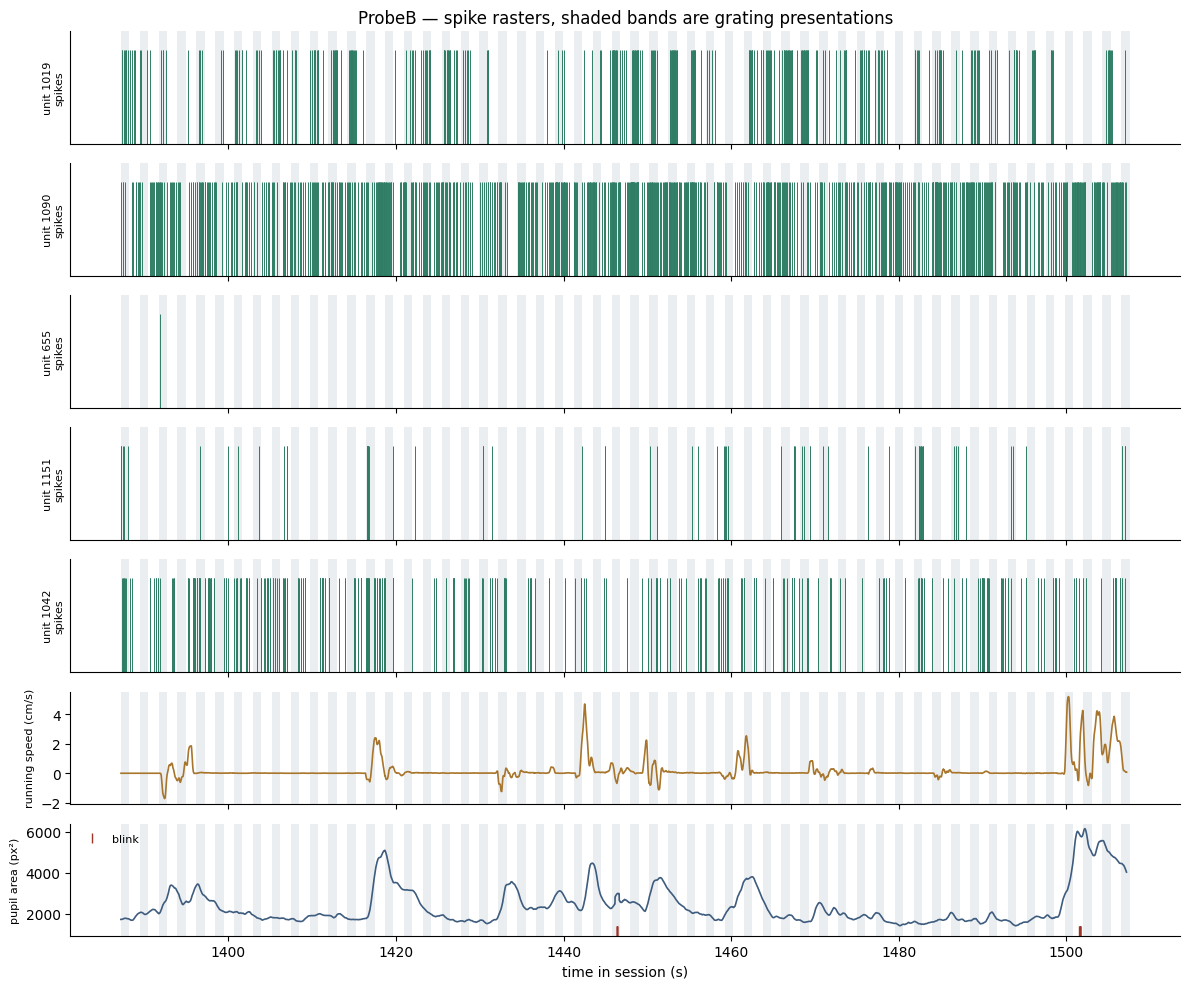

In [11]:
timecourseUnits = exampleUnits[:5]  # top 5 by SNR

# Two minutes partway through the drifting gratings block
windowStart = gratingTrials.start_time.iloc[50]
windowEnd   = windowStart + 120

# Bin width for the raster display (s)
BIN_S = 0.05

binEdges  = np.arange(windowStart, windowEnd + BIN_S, BIN_S)
binCenters = (binEdges[:-1] + binEdges[1:]) / 2

figure, panels = plt.subplots(len(timecourseUnits) + 2, 1,
                               figsize=(12, 10), sharex=True)

for panel, uid in zip(panels, timecourseUnits):
    spikes = np.asarray(nwbfile.units["spike_times"][unitsDf.index.get_loc(uid)])
    inWindow = spikes[(spikes >= windowStart) & (spikes <= windowEnd)]
    panel.vlines(inWindow, 0, 1, color="#2E7D64", linewidth=0.7)
    panel.set_ylim(0, 1.2)
    panel.set_yticks([])
    panel.set_ylabel(f"unit {uid}\nspikes", fontsize=8)

# Running and pupil are sampled near 60 Hz, a
# short rolling average makes the slow changes readable. Both share one window.
smoothingWindow = int(round(0.5 / np.median(np.diff(runningTimes))))

# The animal's behaviour over the same minute.
behaviour = [
    ("running speed (cm/s)", runningTimes,
     pd.Series(runningSpeed).rolling(smoothingWindow, center=True, min_periods=1).mean().to_numpy(),
     "#A8752C"),
    ("pupil area (px²)", pupilTimes,
     pd.Series(pupilArea).rolling(smoothingWindow, center=True, min_periods=1).mean().to_numpy(),
     "#3E5C7E"),
]
for panel, (label, times, values, colour) in zip(panels[len(timecourseUnits):], behaviour):
    inWindow = (times >= windowStart) & (times <= windowEnd)
    panel.plot(times[inWindow], values[inWindow], color=colour, linewidth=1.2)
    panel.set_ylabel(label, fontsize=8)

# Mark the frames flagged as blinks. Notice they correspond to sharp dips in the signal
blinkSeries = nwbfile.processing["eye_tracking"]["likely_blink_times"]
blinkFlags  = np.asarray(blinkSeries.data[:], dtype=bool)
blinkTimes  = np.asarray(blinkSeries.timestamps[:], dtype=float)
blinksShown = blinkTimes[blinkFlags & (blinkTimes >= windowStart) & (blinkTimes <= windowEnd)]

# Plot the blink times below the pupil trace
pupilFloor  = panels[-1].get_ylim()[0]
panels[-1].plot(blinksShown, np.full(blinksShown.shape, pupilFloor),
                linestyle="none", marker="|", markersize=7, color="#A03328", label="blink")
panels[-1].legend(fontsize=8, frameon=False, loc="upper left")

# Mark every grating presentation in the window.
shown = gratingTrials[(gratingTrials.start_time >= windowStart) &
                      (gratingTrials.start_time <= windowEnd)]
for panel in panels:
    for trial in shown.itertuples():
        panel.axvspan(trial.start_time, trial.stop_time,
                      color="#3E5C7E", alpha=0.10, linewidth=0)
    for side in ("top", "right"):
        panel.spines[side].set_visible(False)

panels[-1].set_xlabel("time in session (s)")
panels[0].set_title(f"{probeName} — spike rasters, shaded bands are grating presentations")
figure.tight_layout()
plt.show()

## 8. Receptive fields

During the receptive field block a small grating patch appears at one of 81 grid positions
for 0.25 s, then immediately moves to the next. To find a unit's receptive field we count
its spikes in a short window after each patch onset, then average those responses by grid
position.

Trials follow one another with no gap, so the response window has to be short — about a
third of a second.

In [12]:
RESPONSE_S = 0.3   # response window in seconds

def responses_after_onset(unitIndices, onsets, windowSec=RESPONSE_S):
    """Sum each unit's spikes in a window after every trial onset.

    Returns one row per trial, one column per unit.
    """
    out = np.zeros((len(onsets), len(unitIndices)))
    for col, uid in enumerate(unitIndices):
        spikes = np.asarray(nwbfile.units["spike_times"][unitsDf.index.get_loc(uid)])
        for row, t in enumerate(onsets):
            out[row, col] = ((spikes >= t) & (spikes < t + windowSec)).sum()
    return out

print(f"computing responses for {len(exampleUnits)} units over "
      f"{len(receptiveFieldTrials)} RF trials …")

# How every neuron responded to every patch presentation, from each of the two traces.
patchOnsets   = receptiveFieldTrials.start_time.to_numpy()
patchResponses = responses_after_onset(exampleUnits, patchOnsets)

# Which grid position each trial showed.
xPositions = np.sort(receptiveFieldTrials.x_position.unique())
yPositions = np.sort(receptiveFieldTrials.y_position.unique())
columnIndex = np.searchsorted(xPositions, receptiveFieldTrials.x_position.to_numpy())
rowIndex    = np.searchsorted(yPositions, receptiveFieldTrials.y_position.to_numpy())

# Average the responses at each position, giving rows x columns x neurons per trace.
receptiveFields = np.zeros((len(yPositions), len(xPositions), patchResponses.shape[1]))
for row in range(len(yPositions)):
    for col in range(len(xPositions)):
        here = (rowIndex == row) & (columnIndex == col)
        receptiveFields[row, col] = patchResponses[here].mean(axis=0)

print(f"{len(xPositions)} x {len(yPositions)} grid, "
      f"{int(np.sum((rowIndex == 0) & (columnIndex == 0)))} repeats of each position")

computing responses for 10 units over 4860 RF trials …
9 x 9 grid, 60 repeats of each position


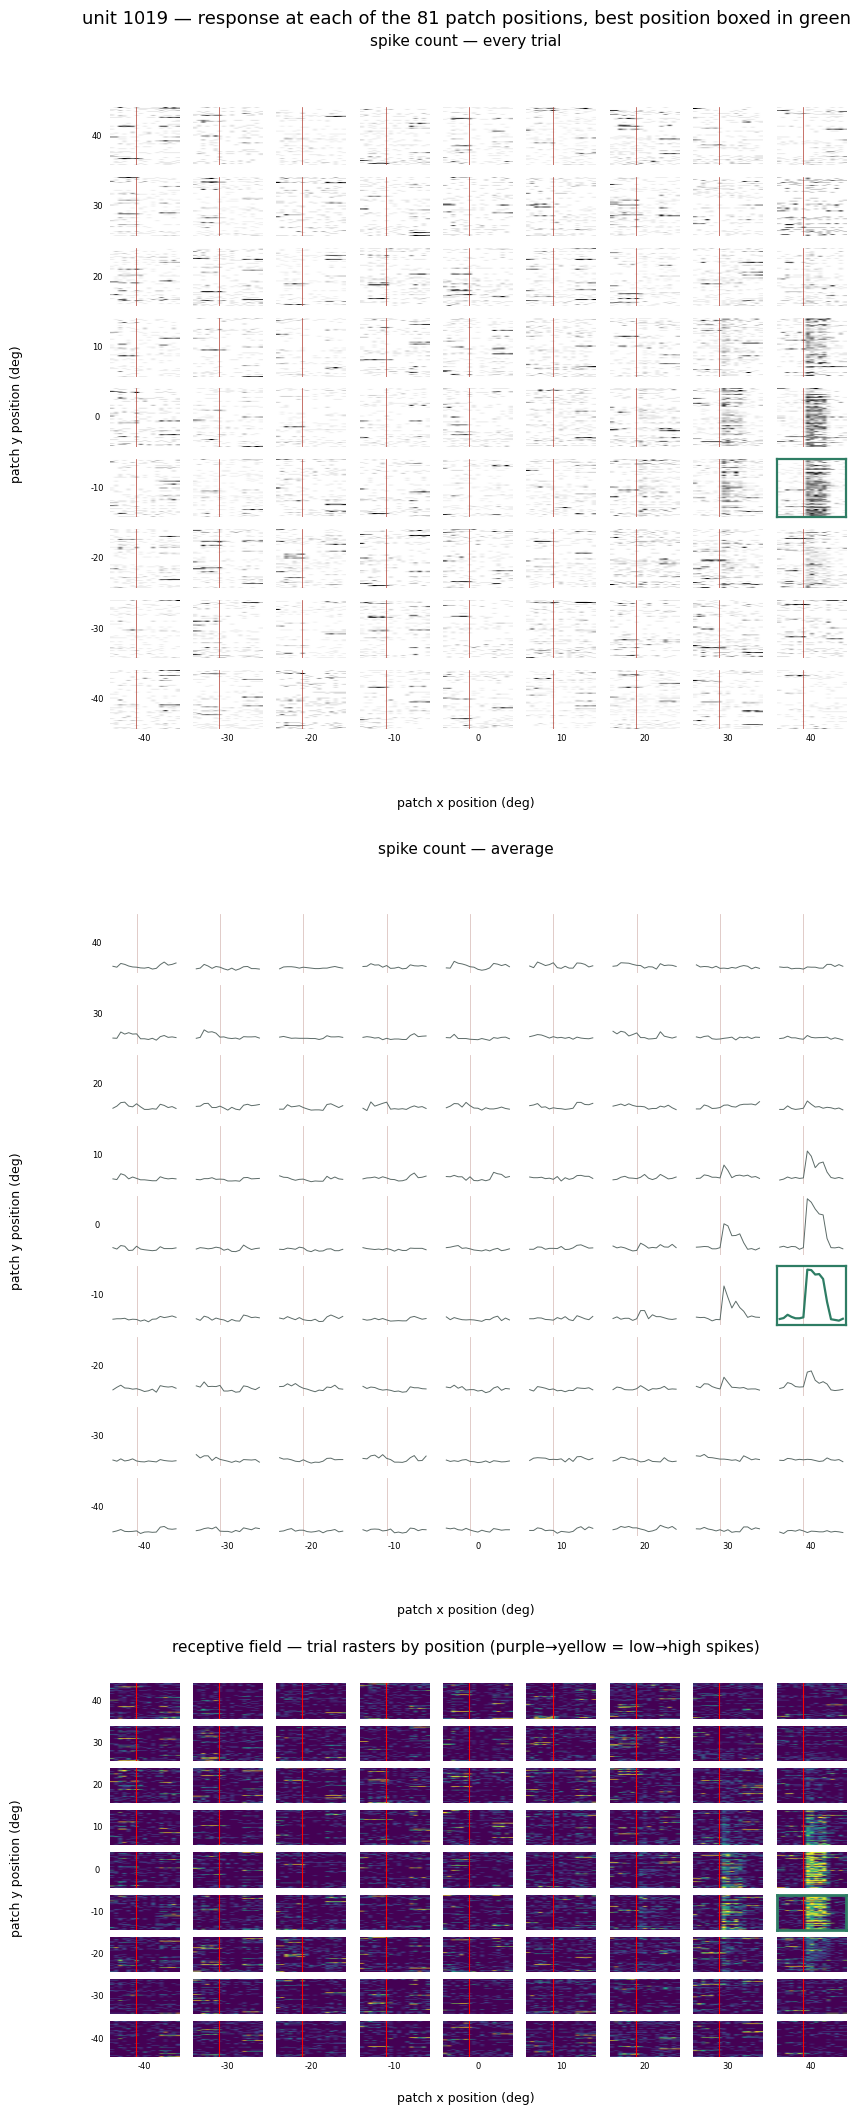

In [13]:
# One unit in detail, before summarising ten of them.

# Pick the unit with the highest SNR
detailUnit = exampleUnits[0]
detailCol  = exampleUnits.index(detailUnit)

# Align spikes to every patch onset using a pre/post window around each onset.
PRESTIM_S  = 0.3   # baseline window before stimulus
POSTSTIM_S = 0.5   # response window after stimulus onset

spikeTimes  = np.asarray(nwbfile.units["spike_times"][unitsDf.index.get_loc(detailUnit)])
patchOnsets = receptiveFieldTrials.start_time.to_numpy()

# Build a time axis and aligned spike matrix: trials x time-bins
binSize  = 0.05
WINDOW_S = np.arange(-PRESTIM_S, POSTSTIM_S + binSize, binSize)
n_pre    = int(round(PRESTIM_S / binSize))

aligned = np.zeros((len(patchOnsets), len(WINDOW_S)))
for t, onset in enumerate(patchOnsets):
    for b, lag in enumerate(WINDOW_S):
        aligned[t, b] = ((spikeTimes >= onset + lag) &
                         (spikeTimes <  onset + lag + binSize)).sum()

# Best grid position for this unit (by raw peak, used to box the best cell)
bestRow, bestColumn = np.unravel_index(
    receptiveFields[:, :, detailCol].argmax(),
    receptiveFields[:, :, detailCol].shape)

# ── Figure: every trial (top), average (middle), and RF map (bottom) ──
figure = plt.figure(figsize=(9.5, 21))
blocks = figure.subfigures(3, 1, hspace=0.0, height_ratios=[1, 1, 0.6])

for blockRow, kind in enumerate(["every trial", "average"]):
    block  = blocks[blockRow]
    panels = block.subplots(len(yPositions), len(xPositions), sharex=True, sharey=True)

    for row in range(len(yPositions)):
        for column in range(len(xPositions)):
            panel = panels[len(yPositions) - 1 - row][column]
            atThisPosition = (rowIndex == row) & (columnIndex == column)
            isBest = (row, column) == (bestRow, bestColumn)

            if kind == "average":
                panel.axvline(0, color="#DCC3BF", linewidth=0.6)
                panel.plot(WINDOW_S, aligned[atThisPosition].mean(axis=0),
                           color="#2E7D64" if isBest else "#5C6B68",
                           linewidth=1.6 if isBest else 0.7)
            else:
                panel.imshow(aligned[atThisPosition], aspect="auto", cmap="Greys",
                             origin="lower",
                             extent=[WINDOW_S[0], WINDOW_S[-1], 0, atThisPosition.sum()])
                panel.axvline(0, color="#B03A2E", linewidth=0.5)

            panel.set_xticks([]); panel.set_yticks([])
            for side in ("top", "right", "bottom", "left"):
                panel.spines[side].set_visible(isBest)
                if isBest:
                    panel.spines[side].set_color("#2E7D64")
                    panel.spines[side].set_linewidth(1.6)

    for column, x in enumerate(xPositions):
        panels[-1][column].set_xlabel(f"{x:.0f}", fontsize=6)
    for row, y in enumerate(yPositions):
        panels[len(yPositions) - 1 - row][0].set_ylabel(f"{y:.0f}", fontsize=6,
                                                         rotation=0, labelpad=9,
                                                         va="center")
    block.supylabel("patch y position (deg)", fontsize=9)
    block.supxlabel("patch x position (deg)", fontsize=9)
    block.suptitle(f"spike count — {kind}", fontsize=11, y=0.97)

pos_win = {}
for row in range(len(yPositions)):
    for column in range(len(xPositions)):
        atThisPosition = (rowIndex == row) & (columnIndex == column)
        pos_win[(row, column)] = aligned[atThisPosition]   # shape: n_trials × n_bins

# Shared color scale across all positions
all_vals = np.concatenate([v.ravel() for v in pos_win.values()])
vmin = float(np.nanpercentile(all_vals, 1))
vmax = float(np.nanpercentile(all_vals, 99))

block  = blocks[2]
panels = block.subplots(len(yPositions), len(xPositions), sharex=True, sharey=True)

for row in range(len(yPositions)):
    for column in range(len(xPositions)):
        panel  = panels[len(yPositions) - 1 - row][column]
        isBest = (row, column) == (bestRow, bestColumn)
        mat    = pos_win[(row, column)]          # n_trials × n_bins

        panel.imshow(mat, aspect="auto", cmap="viridis",
                     vmin=vmin, vmax=vmax, origin="upper",
                     extent=[WINDOW_S[0], WINDOW_S[-1], mat.shape[0], 0])
        panel.axvline(0, color="red", linewidth=0.8)

        panel.set_xticks([]); panel.set_yticks([])
        for side in ("top", "right", "bottom", "left"):
            panel.spines[side].set_visible(isBest)
            if isBest:
                panel.spines[side].set_color("#2E7D64")
                panel.spines[side].set_linewidth(2)

for column, x in enumerate(xPositions):
    panels[-1][column].set_xlabel(f"{x:.0f}", fontsize=6)
for row, y in enumerate(yPositions):
    panels[len(yPositions) - 1 - row][0].set_ylabel(f"{y:.0f}", fontsize=6,
                                                      rotation=0, labelpad=9,
                                                      va="center")
block.supylabel("patch y position (deg)", fontsize=9)
block.supxlabel("patch x position (deg)", fontsize=9)
block.suptitle("receptive field — trial rasters by position (purple→yellow = low→high spikes)",
               fontsize=11, y=0.97)

figure.suptitle(f"unit {detailUnit} — response at each of the 81 patch positions, "
                f"best position boxed in green", fontsize=13, y=1.0)
plt.show()

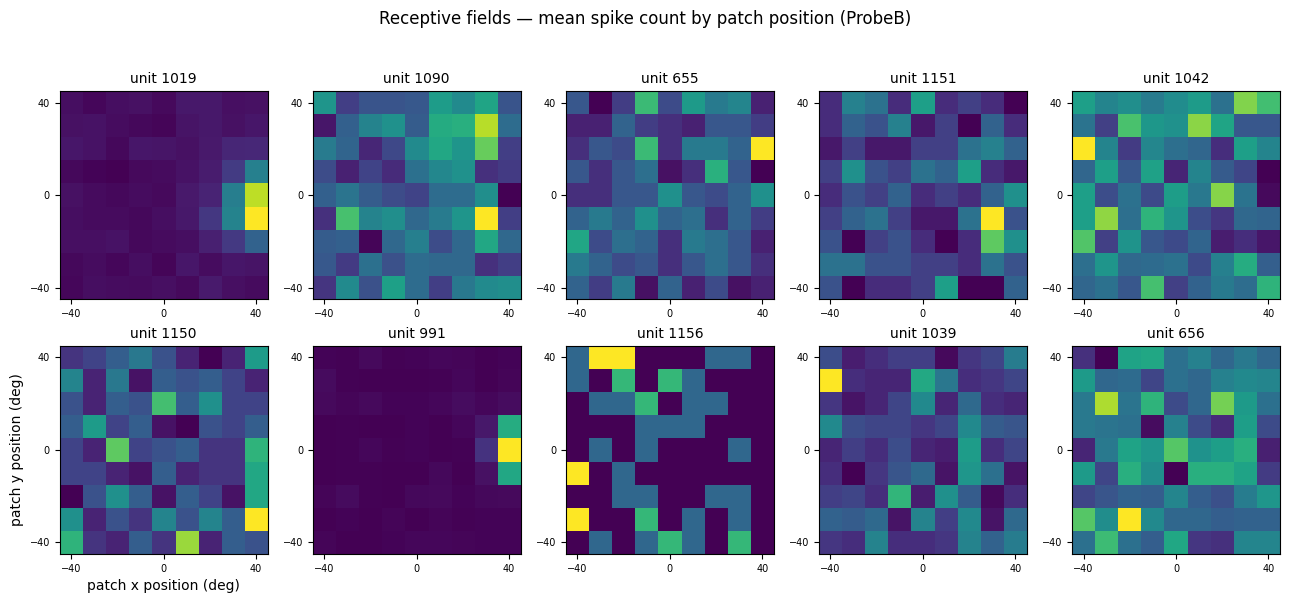

In [14]:
gridEdges = [xPositions.min() - 5, xPositions.max() + 5,
             yPositions.min() - 5, yPositions.max() + 5]

figure, panels = plt.subplots(2, 5, figsize=(13, 6.0))
for panel, uid in zip(panels.flat, exampleUnits):
    col = exampleUnits.index(uid)
    panel.imshow(receptiveFields[:, :, col], origin="lower", cmap="viridis",
                 extent=gridEdges)
    panel.set_title(f"unit {uid}", fontsize=10)
    panel.set_xticks([-40, 0, 40])
    panel.set_yticks([-40, 0, 40])
    panel.tick_params(labelsize=7)

panels[1][0].set_xlabel("patch x position (deg)")
panels[1][0].set_ylabel("patch y position (deg)")
figure.suptitle(f"Receptive fields — mean spike count by patch position ({probeName})",
                fontsize=12)
figure.tight_layout(rect=[0, 0, 1, 0.94], h_pad=2.0)
plt.show()

## 9. Orientation tuning

The drifting gratings block shows a full-field grating for 1 s at a time, cycling through
four orientations and a range of spatial and temporal frequencies. Averaging a unit's
response by orientation — pooling over the other parameters — gives a tuning curve.

Gratings last a full second with a gap between them, so the response window can be longer
than it was for the patches.

These are the same ten units as above, so you can read each one's receptive field and its
orientation preference together.

In [15]:
GRATING_S = 1.0   # gratings last 1 s

gratingOnsets   = gratingTrials.start_time.to_numpy()
gratingResponses = responses_after_onset(probeUnits.index.tolist(), gratingOnsets,
                                         windowSec=GRATING_S)
orientations = np.sort(gratingTrials.orientation.unique())
print("orientations shown:", orientations, "degrees")


def orientation_tuning(unitCol):
    """Mean response and standard error at each orientation, for one unit (by column index)."""
    means, errors = [], []
    for orientation in orientations:
        here = gratingTrials.orientation.to_numpy() == orientation
        responses = gratingResponses[here, unitCol]
        means.append(responses.mean())
        errors.append(responses.std() / np.sqrt(len(responses)))
    return np.array(means), np.array(errors)

orientations shown: [  0.  45.  90. 135.] degrees


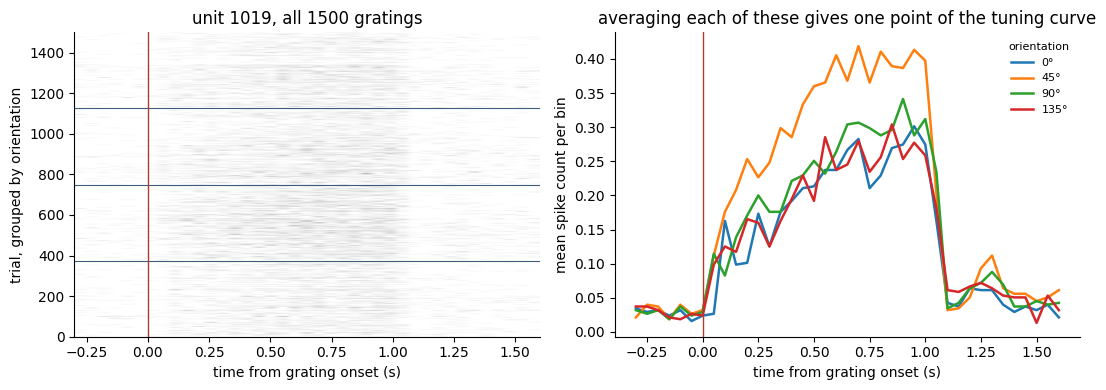

In [16]:
# The same unit, now against grating orientation.
# Align spikes to grating onset using time bins (same approach as the RF cell above).
GRATING_PRE_S  = 0.3    # baseline window before grating onset
GRATING_POST_S = 1.6    # window after grating onset
BIN_S_GRATING  = 0.05   # bin size in seconds

gratingBins    = np.arange(-GRATING_PRE_S, GRATING_POST_S + BIN_S_GRATING, BIN_S_GRATING)
gratingLag     = gratingBins   # time axis for plotting
n_pre_grating  = int(round(GRATING_PRE_S / BIN_S_GRATING))

detailSpikes   = np.asarray(nwbfile.units["spike_times"][unitsDf.index.get_loc(detailUnit)])
gratingOnsets  = gratingTrials.start_time.to_numpy()

# Build aligned matrix: trials × time-bins
alignedGrating = np.zeros((len(gratingOnsets), len(gratingBins)))
for t, onset in enumerate(gratingOnsets):
    for b, lag in enumerate(gratingBins):
        alignedGrating[t, b] = ((detailSpikes >= onset + lag) &
                                 (detailSpikes <  onset + lag + BIN_S_GRATING)).sum()

# Sort trials by orientation so each block of rows is one orientation.
orientations     = np.sort(gratingTrials.orientation.unique())
trialOrientation = gratingTrials.orientation.to_numpy()
byOrientation    = np.argsort(trialOrientation, kind="stable")

figure, (raster, psth) = plt.subplots(1, 2, figsize=(11, 4.0))

raster.imshow(alignedGrating[byOrientation], aspect="auto", cmap="Greys", origin="lower",
              extent=[gratingLag[0], gratingLag[-1], 0, len(byOrientation)])
boundary = 0
for ori in orientations[:-1]:
    boundary += int(np.sum(trialOrientation == ori))
    raster.axhline(boundary, color="#3E5C7E", linewidth=0.8)
raster.axvline(0, color="#B03A2E", linewidth=1)
raster.set(xlabel="time from grating onset (s)", ylabel="trial, grouped by orientation",
           title=f"unit {detailUnit}, all {len(gratingTrials)} gratings")

for ori in orientations:
    atThisOrientation = trialOrientation == ori
    psth.plot(gratingLag, alignedGrating[atThisOrientation].mean(axis=0),
              linewidth=1.8, label=f"{ori:.0f}\u00b0")
psth.axvline(0, color="#B03A2E", linewidth=1)
psth.set(xlabel="time from grating onset (s)", ylabel="mean spike count per bin",
         title="averaging each of these gives one point of the tuning curve")
psth.legend(fontsize=8, frameon=False, title="orientation", title_fontsize=8)

for panel in (raster, psth):
    for side in ("top", "right"):
        panel.spines[side].set_visible(False)
figure.tight_layout()
plt.show()

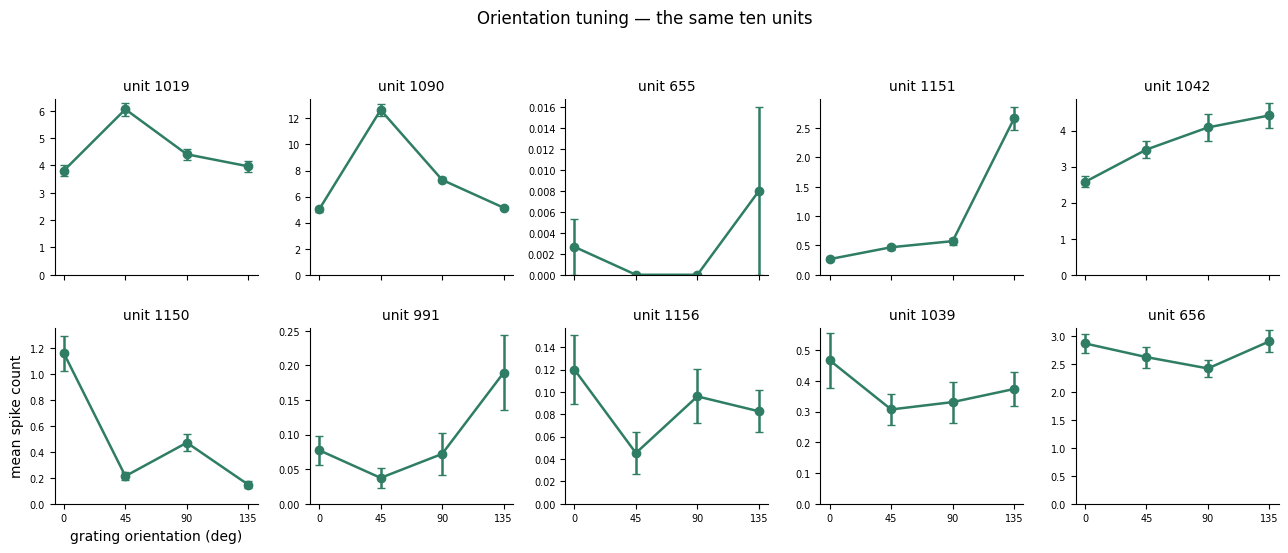

In [17]:
figure, panels = plt.subplots(2, 5, figsize=(13, 5.6), sharex=True)
for panel, uid in zip(panels.flat, exampleUnits):
    col = probeUnits.index.tolist().index(uid)
    means, errors = orientation_tuning(col)
    panel.errorbar(orientations, means, yerr=errors, marker="o", markersize=6,
                   linewidth=1.8, capsize=3, color="#2E7D64")
    panel.set_title(f"unit {uid}", fontsize=10)
    panel.set_xticks(orientations)
    panel.tick_params(labelsize=7)
    panel.set_ylim(bottom=0)
    for side in ("top", "right"):
        panel.spines[side].set_visible(False)

panels[1][0].set_xlabel("grating orientation (deg)")
panels[1][0].set_ylabel("mean spike count")
figure.suptitle("Orientation tuning — the same ten units", fontsize=12)
figure.tight_layout(rect=[0, 0, 1, 0.94], h_pad=2.0)
plt.show()

## 10. Closing the file

Streaming keeps a connection open, so close both handles when you are done.

In [18]:
# fileHandle.close()